# Cloud-Native Export with hms2cng

This notebook demonstrates exporting HEC-HMS model data to cloud-native
geospatial formats using the [hms2cng](https://github.com/gpt-cmdr/hms2cng) package.

| Format | Purpose | Tool |
|--------|---------|------|
| GeoParquet | Columnar spatial data | pyarrow + geopandas |
| PMTiles | Serverless vector tiles | tippecanoe + pmtiles CLI |
| DuckDB | SQL analytics on parquet | duckdb |

**Prerequisites**: `pip install "hms2cng[all]"`

**Estimated Time**: 2-5 minutes

In [1]:
# pip install hms-commander "hms2cng[all]"

**For Development**: If working on hms-commander source code, use the `hmscmdr_local` conda environment (editable install) instead of pip install.

In [2]:
from pathlib import Path
from hms_commander import HmsExamples, init_hms_project, HmsBasin

print("hms-commander loaded")

try:
    from hms2cng import (
        get_basin_layer_gdf,
        export_basin_geometry,
        merge_all_layers,
        export_full_project,
        query_parquet,
        generate_pmtiles_from_input,
    )
    print("hms2cng loaded")
    HMS2CNG_AVAILABLE = True
except ImportError:
    print("hms2cng not installed. Install with: pip install 'hms2cng[all]'")
    HMS2CNG_AVAILABLE = False

hms-commander loaded


hms2cng loaded


## 1. Extract Example Project

In [3]:
project_path = HmsExamples.extract_project(
    "tifton",
    output_path=Path.cwd() / "hms_example_projects" / "tifton_cloud_native"
)
hms = init_hms_project(project_path)

print(f"Project: {hms.project_name}")
print(f"Basin models: {hms.list_basin_names()}")
print(f"Runs: {hms.list_run_names()}")

2026-04-19 18:18:10 - hms_commander.HmsExamples - INFO - Found HMS 4.10 at C:\Program Files\HEC\HEC-HMS\4.10


2026-04-19 18:18:10 - hms_commander.HmsExamples - INFO - Found HMS 4.11 at C:\Program Files\HEC\HEC-HMS\4.11


2026-04-19 18:18:10 - hms_commander.HmsExamples - INFO - Found HMS 4.12 at C:\Program Files\HEC\HEC-HMS\4.12


2026-04-19 18:18:10 - hms_commander.HmsExamples - INFO - Found HMS 4.13 at C:\Program Files\HEC\HEC-HMS\4.13


2026-04-19 18:18:10 - hms_commander.HmsExamples - INFO - Found HMS 4.4.1 at C:\Program Files\HEC\HEC-HMS\4.4.1


...

2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Simulation runs: 1


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Gages: 2


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Paired data tables: 0


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   CRS: Not detected (specify crs_epsg manually)


Project: tifton
Basin models: ['Tifton']
Runs: ['1970 simulation']


## 2. Export Geometry to GeoParquet

Extract basin model geometry as a GeoDataFrame and write to GeoParquet format.
GeoParquet provides columnar storage with ZSTD compression and spatial metadata.

In [4]:
if HMS2CNG_AVAILABLE:
    basin_file = list(project_path.glob("*.basin"))[0]

    # Export subbasins as GeoDataFrame
    gdf_subbasins = get_basin_layer_gdf(basin_file, layer="subbasins")
    print(f"Subbasins: {len(gdf_subbasins)} elements")
    print(f"CRS: {gdf_subbasins.crs}")
    print(f"Columns: {list(gdf_subbasins.columns)}")
    display(gdf_subbasins.head())

2026-04-19 18:18:10 - hms_commander.HmsPrj - WARNING - Could not auto-detect CRS. Specify crs_epsg when calling methods that require coordinate transformation.


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO - HMS project initialized: tifton


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Version: 4.13


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Basin models: 1


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Met models: 1


...

2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   CRS: Not detected (specify crs_epsg manually)


2026-04-19 18:18:10 - hms_commander.HmsBasin - INFO - Reading subbasins from: G:\GH\hms-commander\examples\hms_example_projects\tifton_cloud_native\tifton\Tifton.basin


2026-04-19 18:18:10 - hms_commander.HmsBasin - INFO - Found 1 subbasins


Subbasins: 1 elements
CRS: None
Columns: ['name', 'area', 'downstream', 'loss_method', 'transform_method', 'baseflow_method', 'percent_impervious', 'canvas_x', 'canvas_y', 'geometry']


,name,area,downstream,loss_method,transform_method,baseflow_method,percent_impervious,canvas_x,canvas_y,geometry
0,74006,19.27,Station I,None,Clark,Linear Reservoir,0.0,241449.675574,3.512248e+06,POINT (241449.676 3512247.896)


In [5]:
if HMS2CNG_AVAILABLE:
    output_dir = project_path / "cloud_native_output"
    output_dir.mkdir(exist_ok=True)

    # Write GeoParquet
    parquet_file = output_dir / "subbasins.parquet"
    export_basin_geometry(basin_file, str(parquet_file), layer="subbasins")

    print(f"Written: {parquet_file}")
    print(f"Size: {parquet_file.stat().st_size / 1024:.1f} KB")

2026-04-19 18:18:10 - hms_commander.HmsPrj - WARNING - Could not auto-detect CRS. Specify crs_epsg when calling methods that require coordinate transformation.


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO - HMS project initialized: tifton


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Version: 4.13


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Basin models: 1


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Met models: 1


...

2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   Paired data tables: 0


2026-04-19 18:18:10 - hms_commander.HmsPrj - INFO -   CRS: Not detected (specify crs_epsg manually)


2026-04-19 18:18:10 - hms_commander.HmsBasin - INFO - Reading subbasins from: G:\GH\hms-commander\examples\hms_example_projects\tifton_cloud_native\tifton\Tifton.basin


2026-04-19 18:18:10 - hms_commander.HmsBasin - INFO - Found 1 subbasins


Written: G:\GH\hms-commander\examples\hms_example_projects\tifton_cloud_native\tifton\cloud_native_output\subbasins.parquet
Size: 7.5 KB


### Export All Geometry Layers

Use `merge_all_layers()` to export all available geometry types into a single
GeoParquet file with a `layer` discriminator column.

In [6]:
if HMS2CNG_AVAILABLE:
    gdf_all = merge_all_layers(basin_file)

    print(f"Total elements: {len(gdf_all)}")
    print(f"\nLayers:")
    for layer, count in gdf_all["layer"].value_counts().items():
        print(f"  {layer}: {count}")

    # Write consolidated file
    all_layers_file = output_dir / "all_layers.parquet"
    gdf_all.to_parquet(str(all_layers_file), compression="zstd")
    print(f"\nWritten: {all_layers_file} ({all_layers_file.stat().st_size / 1024:.1f} KB)")

2026-04-19 18:18:11 - hms_commander.HmsPrj - WARNING - Could not auto-detect CRS. Specify crs_epsg when calling methods that require coordinate transformation.


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO - HMS project initialized: tifton


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Version: 4.13


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Basin models: 1


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Met models: 1


...

2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Simulation runs: 1


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Gages: 2


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Paired data tables: 0


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   CRS: Not detected (specify crs_epsg manually)


Total elements: 2

Layers:
  subbasins: 1
  junctions: 1

Written: G:\GH\hms-commander\examples\hms_example_projects\tifton_cloud_native\tifton\cloud_native_output\all_layers.parquet (8.1 KB)


## 3. Query with DuckDB

Query GeoParquet files directly with SQL using DuckDB.
No database server needed -- queries run in-process.

In [7]:
if HMS2CNG_AVAILABLE:
    # Query subbasin areas
    result = query_parquet(
        str(parquet_file),
        "SELECT name, area, loss_method, transform_method FROM _ ORDER BY name"
    )
    print("Subbasin Summary (DuckDB query):")
    display(result)

Subbasin Summary (DuckDB query):


,name,area,loss_method,transform_method
0,74006,19.27,<NA>,Clark


In [8]:
if HMS2CNG_AVAILABLE:
    # Query the consolidated file by layer
    result = query_parquet(
        str(all_layers_file),
        """
        SELECT layer, COUNT(*) as count
        FROM _
        GROUP BY layer
        ORDER BY count DESC
        """
    )
    print("Elements by layer:")
    display(result)

Elements by layer:


,layer,count
0,subbasins,1
1,junctions,1


## 4. Full Project Export

Export an entire HMS project (all basins + all runs) into a single
consolidated GeoParquet file with a manifest.json catalog.

In [9]:
if HMS2CNG_AVAILABLE:
    hms_file = list(project_path.glob("*.hms"))[0]
    archive_dir = output_dir / "archive"

    export_full_project(str(hms_file), str(archive_dir))

    # Show what was created
    print("Archive contents:")
    for f in sorted(archive_dir.iterdir()):
        size = f.stat().st_size / 1024
        print(f"  {f.name}: {size:.1f} KB")

2026-04-19 18:18:11 - hms_commander.HmsPrj - WARNING - Could not auto-detect CRS. Specify crs_epsg when calling methods that require coordinate transformation.


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO - HMS project initialized: tifton


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Version: 4.13


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Basin models: 1


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Met models: 1


...

2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Gages: 2


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   Paired data tables: 0


2026-04-19 18:18:11 - hms_commander.HmsPrj - INFO -   CRS: Not detected (specify crs_epsg manually)


G:\GH\hms2cng\hms2cng\results.py:581: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(all_parts, ignore_index=True)


Archive contents:
  manifest.json: 1.0 KB
  tifton.parquet: 20.8 KB


In [10]:
if HMS2CNG_AVAILABLE:
    import json

    manifest_file = archive_dir / "manifest.json"
    if manifest_file.exists():
        manifest = json.loads(manifest_file.read_text())
        print(f"Project: {manifest.get('project_name')}")
        print(f"HMS Version: {manifest.get('hms_version')}")
        print(f"Total rows: {manifest.get('total_rows')}")
        print(f"\nLayers:")
        for layer in manifest.get("layers", []):
            print(f"  {layer['name']}: {layer['rows']} rows ({layer['geometry_type']})")

Project: tifton
HMS Version: 4.13
Total rows: 10

Layers:
  subbasins: 1 rows (Point)
  junctions: 1 rows (Point)
  outflow: 2 rows (Point)
  inflow: 2 rows (Point)
  stage: 2 rows (Point)
  depth: 2 rows (Point)


## 5. Generate PMTiles for Web Maps

Convert GeoParquet to PMTiles format for serverless web map visualization.
PMTiles uses HTTP range requests -- no tile server needed.

**Requires**: `tippecanoe` and `pmtiles` CLI tools.
Install with: `conda install -c conda-forge tippecanoe pmtiles`

In [11]:
if HMS2CNG_AVAILABLE:
    import shutil

    pmtiles_file = output_dir / "subbasins.pmtiles"

    if shutil.which("tippecanoe") and shutil.which("pmtiles"):
        generate_pmtiles_from_input(
            str(parquet_file),
            str(pmtiles_file),
            min_zoom=5,
            max_zoom=15,
            layer_name="subbasins"
        )
        print(f"PMTiles: {pmtiles_file} ({pmtiles_file.stat().st_size / 1024:.1f} KB)")
    else:
        print("tippecanoe/pmtiles CLI not found.")
        print("Install with: conda install -c conda-forge tippecanoe pmtiles")
        print("Skipping PMTiles generation.")

tippecanoe/pmtiles CLI not found.
Install with: conda install -c conda-forge tippecanoe pmtiles
Skipping PMTiles generation.


## 6. Visualize with Leafmap

Display the exported geometry on an interactive web map using leafmap.

No CRS detected -- using matplotlib fallback (schematic coordinates).


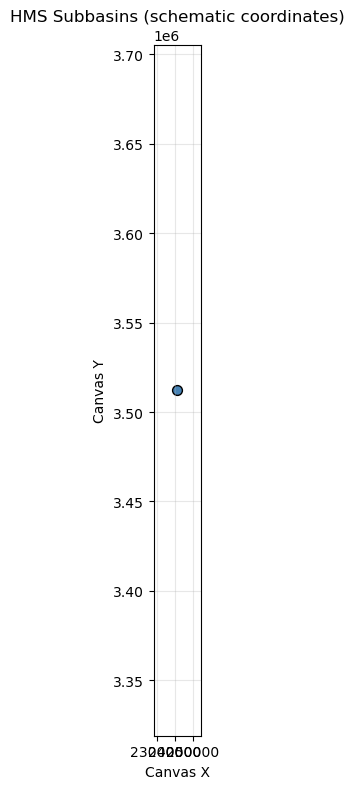

In [12]:
if HMS2CNG_AVAILABLE:
    import geopandas as gpd

    gdf = gpd.read_parquet(str(parquet_file))

    if gdf.crs is not None:
        try:
            import leafmap

            if gdf.crs.to_epsg() != 4326:
                gdf = gdf.to_crs(epsg=4326)

            bounds = gdf.total_bounds
            center_lat = (bounds[1] + bounds[3]) / 2
            center_lon = (bounds[0] + bounds[2]) / 2

            m = leafmap.Map(center=(center_lat, center_lon), zoom=10)
            m.add_gdf(gdf, layer_name="Subbasins", style={"color": "blue", "weight": 2})
            display(m)
        except ImportError:
            print("leafmap not installed. Install with: pip install leafmap")
    else:
        print("No CRS detected -- using matplotlib fallback (schematic coordinates).")
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10, 8))
        gdf.plot(ax=ax, color="steelblue", edgecolor="black", markersize=50)
        ax.set_title("HMS Subbasins (schematic coordinates)")
        ax.set_xlabel("Canvas X")
        ax.set_ylabel("Canvas Y")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 7. CLI Quick Reference

hms2cng provides a command-line interface for all export operations:

| Command | Purpose |
|---------|---------|
| `hms2cng geometry basin.basin out.parquet` | Export geometry layer |
| `hms2cng results project/ out.parquet` | Export results with spatial join |
| `hms2cng project project.hms out_dir/` | Full project archive |
| `hms2cng pmtiles data.parquet out.pmtiles` | Generate vector tiles |
| `hms2cng query data.parquet "SQL"` | DuckDB SQL query |
| `hms2cng sync data.parquet connstr table` | Upload to PostGIS |
| `hms2cng manifest project.hms` | Show project metadata |

## Summary

This notebook demonstrated cloud-native export of HMS model data:

| Step | Tool | Output |
|------|------|--------|
| Geometry export | `get_basin_layer_gdf()` | GeoDataFrame |
| Write parquet | `export_basin_geometry()` | GeoParquet file |
| All layers | `merge_all_layers()` | Consolidated GeoParquet |
| Full project | `export_full_project()` | Parquet + manifest.json |
| SQL analytics | `query_parquet()` | DataFrame from DuckDB |
| Vector tiles | `generate_pmtiles_from_input()` | PMTiles file |
| Visualization | leafmap / matplotlib | Interactive web map |

## Next Steps

- **20_pmtiles_web_map.ipynb**: Advanced PMTiles visualization with styled layers
- **06_results_dss.ipynb**: DSS-based results extraction
- **hms2cng docs**: https://hms2cng.readthedocs.io/